In [1]:
# Install yfinance to fetch real crypto price data
import subprocess
subprocess.run(["pip", "install", "yfinance", "--break-system-packages", "-q"])

import yfinance as yf
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Download Bitcoin and Ethereum daily price data
# From before the conflict started through today
btc = yf.download("BTC-USD", start="2023-10-01", end="2026-04-05", auto_adjust=True)
eth = yf.download("ETH-USD", start="2023-10-01", end="2026-04-05", auto_adjust=True)

# Keep only the closing price
btc = btc[["Close"]].rename(columns={"Close": "BTC_Close"})
eth = eth[["Close"]].rename(columns={"Close": "ETH_Close"})

# Combine into one dataframe
prices = btc.join(eth, how="inner")
prices.index = pd.to_datetime(prices.index)

print("Data shape:", prices.shape)
print("\nFirst few rows:")
print(prices.head())
print("\nLast few rows:")
print(prices.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data shape: (917, 2)

First few rows:
Price          BTC_Close    ETH_Close
Ticker           BTC-USD      ETH-USD
Date                                 
2023-10-01  27983.750000  1733.810425
2023-10-02  27530.785156  1663.627563
2023-10-03  27429.978516  1656.685669
2023-10-04  27799.394531  1647.838135
2023-10-05  27415.912109  1611.476440

Last few rows:
Price          BTC_Close    ETH_Close
Ticker           BTC-USD      ETH-USD
Date                                 
2026-03-31  68233.312500  2104.708252
2026-04-01  68078.554688  2138.737061
2026-04-02  66888.570312  2056.852539
2026-04-03  66931.101562  2053.385254
2026-04-04  67290.515625  2065.351562


In [3]:
# Create SQLite database
conn = sqlite3.connect("crypto_geopolitical.db")

# Flatten the multi-level column index from yfinance
prices.columns = ["BTC_Close", "ETH_Close"]
prices.index.name = "Date"

# Save to database
prices.to_sql("crypto_prices", conn, if_exists="replace", index=True)

# Define all key geopolitical events
events = pd.DataFrame([
    ("2023-10-07", "Hamas attacks Israel — conflict begins"),
    ("2024-04-01", "Israel strikes Iranian consulate in Damascus"),
    ("2024-04-13", "Iran launches 300+ drones and missiles at Israel"),
    ("2024-04-19", "Israel retaliates — strikes near Isfahan"),
    ("2024-07-31", "Assassination of Haniyeh in Tehran"),
    ("2024-10-01", "Iran launches 180 ballistic missiles at Israel"),
    ("2024-10-26", "Israel's largest direct strike on Iran"),
    ("2025-06-13", "Twelve-Day War begins — Israel bombs Iran"),
    ("2026-02-28", "US-Israel launch major strikes on Iran"),
], columns=["event_date", "event_description"])

# Save events to database
events.to_sql("geopolitical_events", conn, if_exists="replace", index=False)

print("Database created successfully!")
print("\nTables in database:")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

Database created successfully!

Tables in database:
                  name
0        crypto_prices
1  geopolitical_events


In [7]:
query1 = """
SELECT 
    e.event_date,
    e.event_description,
    ROUND(c.BTC_Close, 2) AS BTC_Price,
    ROUND(c.ETH_Close, 2) AS ETH_Price
FROM geopolitical_events e
JOIN crypto_prices c ON e.event_date = DATE(c.Date)
ORDER BY e.event_date
"""

result1 = pd.read_sql(query1, conn)
print("BTC and ETH prices on key conflict dates:\n")
print(result1.to_string(index=False))

BTC and ETH prices on key conflict dates:

event_date                                event_description  BTC_Price  ETH_Price
2023-10-07           Hamas attacks Israel — conflict begins   27968.84    1634.51
2024-04-01     Israel strikes Iranian consulate in Damascus   69702.15    3505.03
2024-04-13 Iran launches 300+ drones and missiles at Israel   63821.47    3004.90
2024-04-19         Israel retaliates — strikes near Isfahan   63843.57    3059.28
2024-07-31               Assassination of Haniyeh in Tehran   64619.25    3231.30
2024-10-01   Iran launches 180 ballistic missiles at Israel   60837.01    2448.92
2024-10-26           Israel's largest direct strike on Iran   67014.70    2479.60
2025-06-13        Twelve-Day War begins — Israel bombs Iran  106090.97    2579.49
2026-02-28           US-Israel launch major strikes on Iran   66995.86    1965.05


In [8]:
# Check how dates are stored in each table
print("Sample dates from crypto_prices:")
print(pd.read_sql("SELECT Date FROM crypto_prices LIMIT 3", conn))

print("\nSample dates from geopolitical_events:")
print(pd.read_sql("SELECT event_date FROM geopolitical_events LIMIT 3", conn))

Sample dates from crypto_prices:
                  Date
0  2023-10-01 00:00:00
1  2023-10-02 00:00:00
2  2023-10-03 00:00:00

Sample dates from geopolitical_events:
   event_date
0  2023-10-07
1  2024-04-01
2  2024-04-13


In [9]:
query2 = """
SELECT 
    e.event_date,
    e.event_description,
    ROUND(c1.BTC_Close, 2) AS BTC_On_Event,
    ROUND(c2.BTC_Close, 2) AS BTC_3Days_Later,
    ROUND((c2.BTC_Close - c1.BTC_Close) / c1.BTC_Close * 100, 2) AS BTC_Change_Pct,
    ROUND(c1.ETH_Close, 2) AS ETH_On_Event,
    ROUND(c2.ETH_Close, 2) AS ETH_3Days_Later,
    ROUND((c2.ETH_Close - c1.ETH_Close) / c1.ETH_Close * 100, 2) AS ETH_Change_Pct
FROM geopolitical_events e
JOIN crypto_prices c1 ON e.event_date = DATE(c1.Date)
JOIN crypto_prices c2 ON DATE(c2.Date) = DATE(e.event_date, '+3 days')
ORDER BY e.event_date
"""

result2 = pd.read_sql(query2, conn)
print("Price change 3 days after each conflict event:\n")
print(result2[["event_date", "event_description", "BTC_Change_Pct", "ETH_Change_Pct"]].to_string(index=False))

Price change 3 days after each conflict event:

event_date                                event_description  BTC_Change_Pct  ETH_Change_Pct
2023-10-07           Hamas attacks Israel — conflict begins           -2.07           -4.09
2024-04-01     Israel strikes Iranian consulate in Damascus           -1.71           -4.99
2024-04-13 Iran launches 300+ drones and missiles at Israel           -0.02            2.66
2024-04-19         Israel retaliates — strikes near Isfahan            4.69            4.65
2024-07-31               Assassination of Haniyeh in Tehran           -6.10          -10.15
2024-10-01   Iran launches 180 ballistic missiles at Israel            2.02           -1.39
2024-10-26           Israel's largest direct strike on Iran            8.51            6.39
2025-06-13        Twelve-Day War begins — Israel bombs Iran            0.67           -1.51
2026-02-28           US-Israel launch major strikes on Iran            1.94            0.90


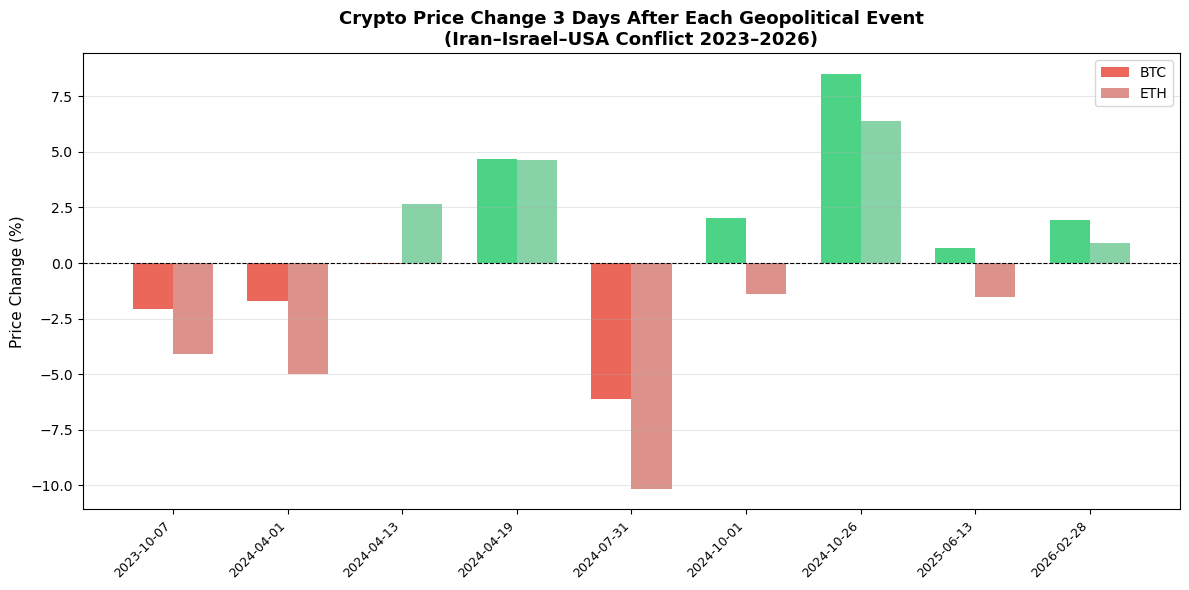

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(result2))
width = 0.35

btc_bars = ax.bar([i - width/2 for i in x], result2["BTC_Change_Pct"], 
                   width, label="BTC", color=["#e74c3c" if v < 0 else "#2ecc71" 
                   for v in result2["BTC_Change_Pct"]], alpha=0.85)

eth_bars = ax.bar([i + width/2 for i in x], result2["ETH_Change_Pct"], 
                   width, label="ETH", color=["#c0392b" if v < 0 else "#27ae60" 
                   for v in result2["ETH_Change_Pct"]], alpha=0.55)

ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(list(x))
ax.set_xticklabels(result2["event_date"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Price Change (%)", fontsize=11)
ax.set_title("Crypto Price Change 3 Days After Each Geopolitical Event\n(Iran–Israel–USA Conflict 2023–2026)", 
             fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
query3 = """
SELECT
    e.event_date,
    e.event_description,
    ROUND(AVG(ABS(c.BTC_Close - 
        (SELECT BTC_Close FROM crypto_prices 
         WHERE DATE(Date) = e.event_date))) , 2) AS BTC_Avg_Deviation,
    ROUND(MAX(c.BTC_Close) - MIN(c.BTC_Close), 2) AS BTC_Price_Range,
    ROUND(MAX(c.ETH_Close) - MIN(c.ETH_Close), 2) AS ETH_Price_Range
FROM geopolitical_events e
JOIN crypto_prices c 
    ON DATE(c.Date) BETWEEN DATE(e.event_date, '-3 days') 
    AND DATE(e.event_date, '+3 days')
GROUP BY e.event_date
ORDER BY BTC_Price_Range DESC
"""

result3 = pd.read_sql(query3, conn)
print("Price volatility in 7-day window around each event (ranked by BTC range):\n")
print(result3[["event_date", "event_description", "BTC_Price_Range", "ETH_Price_Range"]].to_string(index=False))

Price volatility in 7-day window around each event (ranked by BTC range):

event_date                                event_description  BTC_Price_Range  ETH_Price_Range
2024-07-31               Assassination of Haniyeh in Tehran          7575.77           417.15
2024-04-13 Iran launches 300+ drones and missiles at Israel          7161.67           538.84
2024-10-26           Israel's largest direct strike on Iran          6288.30           202.02
2024-04-01     Israel strikes Iranian consulate in Damascus          5886.68           370.62
2024-04-19         Israel retaliates — strikes near Isfahan          5560.99           216.92
2024-10-01   Iran launches 180 ballistic missiles at Israel          5254.86           327.75
2025-06-13        Twelve-Day War begins — Israel bombs Iran          4784.83           280.07
2026-02-28           US-Israel launch major strikes on Iran          3037.75           123.87
2023-10-07           Hamas attacks Israel — conflict begins           577.82   

## Key Findings

### Finding 1: Crypto drops on unexpected shocks, not anticipated escalations
Early conflict events (Oct 2023, Apr 2024) caused consistent price drops.
By 2025–2026, even major military strikes caused minimal or positive reactions,
suggesting markets had priced in the ongoing conflict risk.

### Finding 2: The Haniyeh assassination was the single most disruptive event
BTC fell -6.10% and ETH fell -10.15% in the 3 days following July 31 2024.
It also caused the highest 7-day price range of $7,575 — more than the
Twelve-Day War itself. Unexpected political assassinations create more
crypto volatility than anticipated military operations.

### Finding 3: Market desensitization over time
7-day BTC volatility dropped from $7,575 (Jul 2024) to $3,037 (Feb 2026)
despite escalating military intensity. Crypto markets appear to normalize
conflict risk when geopolitical tensions persist over extended periods.

### Finding 4: ETH more sensitive than BTC to geopolitical shocks
ETH consistently showed larger percentage moves than BTC in both directions,
suggesting it carries higher geopolitical beta — more reactive to 
risk-on/risk-off sentiment shifts.

## Conclusion
Cryptocurrency markets do not respond uniformly to geopolitical conflict.
The nature of the event (unexpected vs anticipated), its timing, and
cumulative conflict exposure all influence market reaction. This analysis
suggests crypto increasingly behaves as a risk asset that prices in
sustained geopolitical risk rather than reacting to each new escalation.